In [ ]:
%pip install drama

# notebook No-DRaMA

author: Wietske Brouwer \
date: 27-02-2024 \

In this notebook we provide examples for the No-DRaMA software. We will show four different examples.
The theory behind the viewing geometry can be found in this paper: https://ieeexplore.ieee.org/abstract/document/10273425/metrics#metrics

## Prerequisites:
To run the notebook you need to have saved the Sentinel-1 configuration file and .csv file with city cooridates to your computer. 

### Example 1: Estimate viewing geometry for one particular location on Earth
For one location on earth, defined by a latitudinal and longitudinal coordinate, we compute the viewing geometry of the available acquisitions

### Example 2: Compute the orientation of the null-line
For the location in example 1 we compute the orientation of the null-line. If there are more acquisitions we can compute the orientation of multiple null lines. 

### Example 3: Estimate the viewing geometry for a list of coordinates
Here we saved a list of coordinates for different cities over the world to a .csv file. We load the coordinates of these cities and we compute the viewing geometries of the available acquisitions.

### Example 4: Estimate the viewing geometry for a grid of coordinates
We can also compute and plot the viewing gemoetry for a grid of coordinates (so basically the entire world). When we then combine the ascending and descending acquisitions, we can compute the orientation of the null line. 

### Example 5: Compute the relation between the incidence angle $\theta$ and the azimuth of the ZDP $\alpha_d$. 
For locations on Earth seen by multiple acquisitions we can compute the relation between the incidence angle and the azimuth of the ZDP. 


In [ ]:
%matplotlib inline

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import pandas as pd

from drama.performance.sar import SARModeFromCfg
from drama.io import cfg
from drama.mission.timeline import LatLonTimeline

import drama.mission.timeline.no_drama as nd
import pickle
import os



# Load the parameter file with the orbit data of sentinel

1. The parameter file contains information on the position and the orbit of Sentinel1
2. Change the second parameter of `SARModeFromCfg` to the acquisition mode of interest: `"IWS"`, `"EW"`, `"WM"`, `"stripmap"`.
3. The orbit resolution determines how precise the orbits are estimated. 

# <font color='blue'>Example 1:</font> Estimate the viewing geometry for one particular location on Earth

The pickled geometry has the following information:
1. nr_asc_obs: list of the number of available ascending observations for particular location
2. nr_desc_obs: list of the number of available descending observations for particular location
3. asc_inc: list of the incidence angles of the ascending acquisitions per location 
4. desc_inc: list of the incidence angles of the descending acquisitions per location  
5. asc_alpha: list of the azimuth of the ZDP of the ascending acquisitions per location  
6. desc_alpha: list of the azimuth of the ZDP of the descending acquisitions per location

# We can compare Krakow and Svalbard

Krakow position is latitude = 50.049683 and longitude= 19.944544

Svaldbard position is Latitude = 79,004559 and longitude= 17,666017



In [35]:


data = 'viewing_geometry_krakow.pkl'
#path = os.path.join(os.getcwd(), data)

#join path with the current working directory

with open(data, 'rb') as f:
    results = pickle.load(f)

nr_asc_obs_krakow = results['nr_asc_obs']
nr_desc_obs_krakow = results['nr_desc_obs']
asc_inc_krakow = results['asc_inc']
desc_inc_krakow = results['desc_inc']
asc_alpha_krakow = results['asc_alpha']
desc_alpha_krakow = results['desc_alpha']

print("Results for Krakow loaded!")

data = 'viewing_geometry_svalbard.pkl'
#path = os.path.join(os.getcwd(), data)

with open(data, 'rb') as f:
    results = pickle.load(f)

nr_asc_obs_svalbard = results['nr_asc_obs']
nr_desc_obs_svalbard = results['nr_desc_obs']
asc_inc_svalbard = results['asc_inc']
desc_inc_svalbard = results['desc_inc']
asc_alpha_svalbard = results['asc_alpha']
desc_alpha_svalbard = results['desc_alpha'] 

print("Results for Svalbard loaded!")

Results for Krakow loaded!
Results for Svalbard loaded!


Putting it in a dataframe just to visualise and compare

In [36]:
def geometry_to_dict(lat, lon, nr_asc, asc_inc, asc_alpha, nr_desc, desc_inc, desc_alpha):
    d = {'lat': lat, 'lon': lon, 'nr_asc_obs': nr_asc, 'nr_desc_obs': nr_desc}
    
    for k in range(3):
        d[f'asc_inc{k+1}']    = np.rad2deg(asc_inc[0][k])    if k < np.size(asc_inc[0])    else np.nan
        d[f'asc_alpha{k+1}']  = np.rad2deg(asc_alpha[0][k])  if k < np.size(asc_alpha[0])  else np.nan
        d[f'desc_inc{k+1}']   = np.rad2deg(desc_inc[0][k])   if k < np.size(desc_inc[0])   else np.nan
        d[f'desc_alpha{k+1}'] = np.rad2deg(desc_alpha[0][k]) if k < np.size(desc_alpha[0]) else np.nan
    return d

rows = {
    'Krakow':   geometry_to_dict(50.049683, 19.944544,
                                 nr_asc_obs_krakow,   asc_inc_krakow,   asc_alpha_krakow,
                                 nr_desc_obs_krakow,  desc_inc_krakow,  desc_alpha_krakow),
    'Svalbard': geometry_to_dict(79.004559, 17.666017,
                                 nr_asc_obs_svalbard, asc_inc_svalbard, asc_alpha_svalbard,
                                 nr_desc_obs_svalbard, desc_inc_svalbard, desc_alpha_svalbard),
}

df = pd.DataFrame.from_dict(rows, orient='index')
df.index.name = 'Location'
df

,lat,lon,nr_asc_obs,nr_desc_obs,asc_inc1,asc_alpha1,desc_inc1,desc_alpha1,asc_inc2,asc_alpha2,desc_inc2,desc_alpha2,asc_inc3,asc_alpha3,desc_inc3,desc_alpha3
Location,,,,,,,,,,,,,,,,
Krakow,50.049683,19.944544,2,1,36.075718,259.401848,38.124704,100.210118,44.466359,260.985411,NaN,NaN,NaN,NaN,NaN,NaN
Svalbard,79.004559,17.666017,6,7,32.369418,243.927313,38.581357,111.170138,44.448785,253.877078,43.286366,107.143686,39.905911,249.89408,30.900582,117.128419


# <font color='blue'>Example 2:</font> Estimate and visualize the orientation of the null line for a particular location

For a location on earth we can estimate the orientation of the null line with `phi_zeta` and corresponing viewing geometry.
In the example below we compute the orientation of the null line for the location we defined in example 1.

Note that when there are multiple ascending and/or descending acquisitions available, we can compute the multiple null lines by combining different ascending and descending acquisitions. 

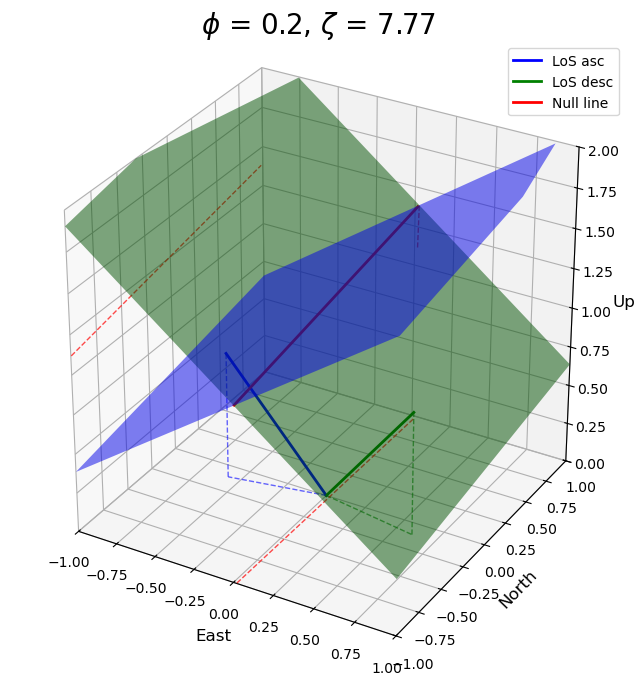

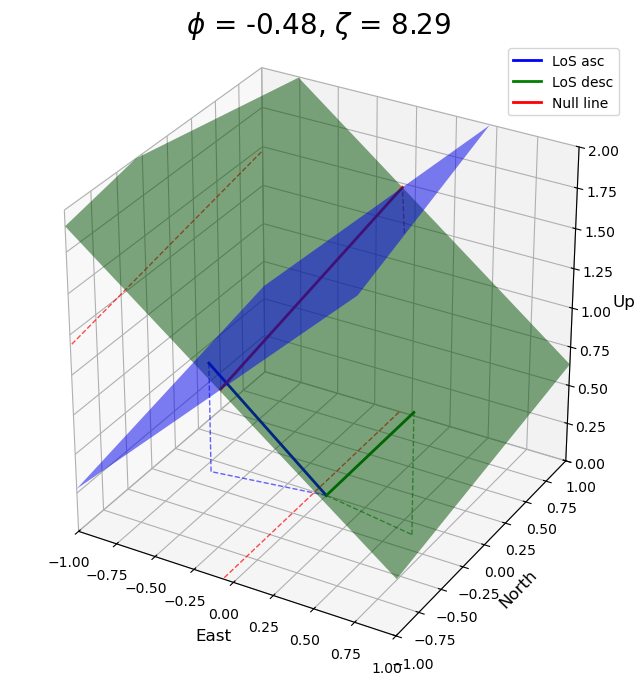

In [37]:

inc_a = asc_inc_krakow[0] #can also be set to asc_inc_krakow[0]
inc_d = desc_inc_krakow[0] #can also be set to desc_inc_krakow[0]
alpha_asc = asc_alpha_krakow[0] #can also be set to asc_alpha_krakow[0]
alpha_desc = desc_alpha_krakow[0] #can also be set to desc_alpha_krakow[0]

phi = np.zeros((np.size(inc_a), np.size(inc_d)))
zeta = np.zeros((np.size(inc_a), np.size(inc_d)))

for i in range(np.size(inc_a)):
    for j in range(np.size(inc_d)):
        inc = np.array([inc_a[i], inc_d[j]])
        alpha_d = np.array([alpha_asc[i], alpha_desc[j]])
        
        unit_los_enu, zeta[i,j], phi[i,j], xi = nd.null_space_2sat(inc, alpha_d, 1, 'LoS asc', 'LoS desc')


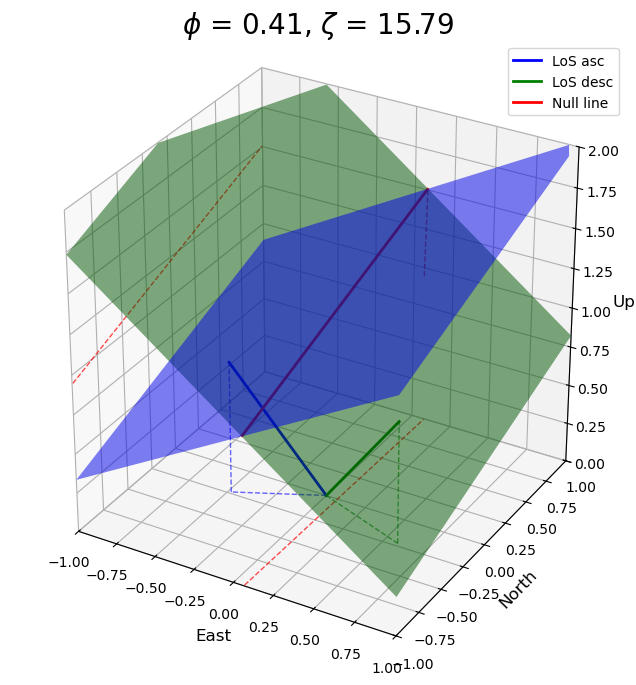

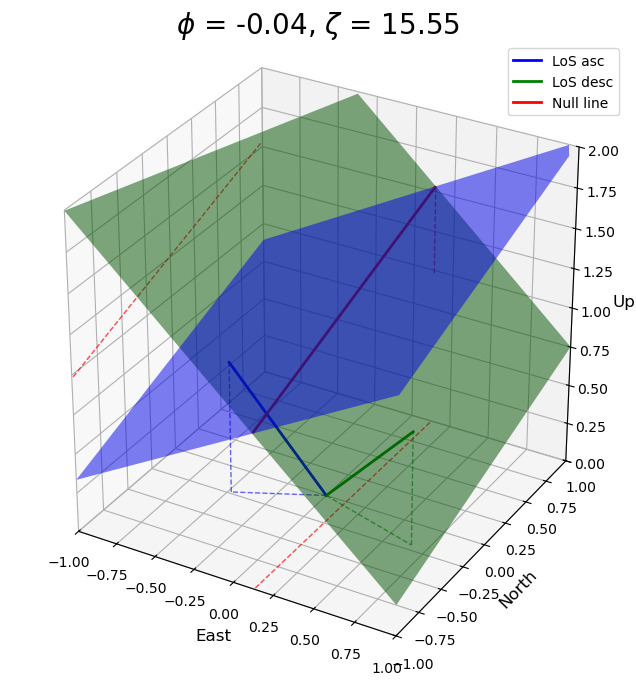

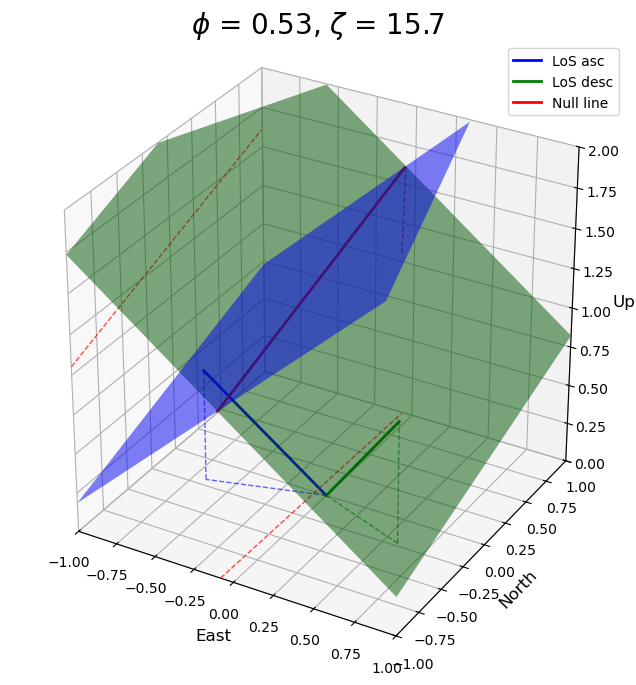

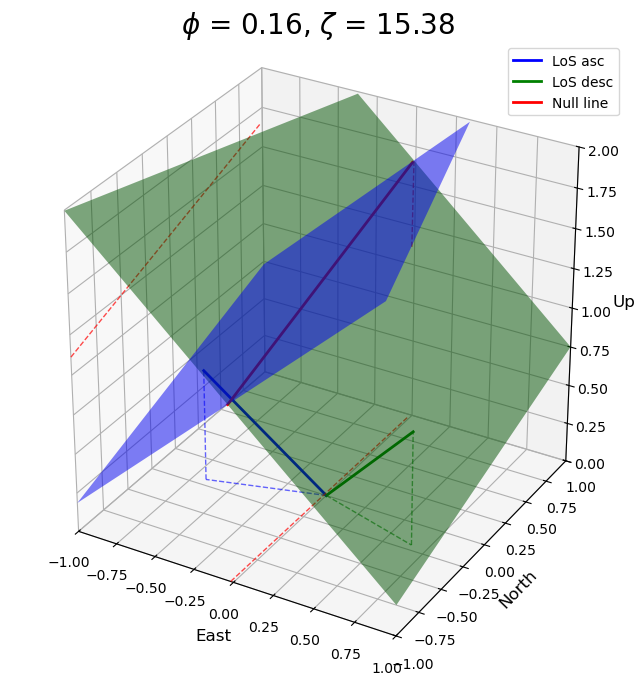

In [38]:
#Svalbard has a lot more observations, lets pick a couple of them

inc_a = asc_inc_svalbard[0][:2]   # picking the first 2 ascending observations
inc_d = desc_inc_svalbard[0][:2]  # picking the first 2 descending observations
alpha_asc = asc_alpha_svalbard[0][:2]
alpha_desc = desc_alpha_svalbard[0][:2]
phi = np.zeros((np.size(inc_a), np.size(inc_d)))
zeta = np.zeros((np.size(inc_a), np.size(inc_d)))

for i in range(np.size(inc_a)):
    for j in range(np.size(inc_d)):
        inc = np.array([inc_a[i], inc_d[j]])
        alpha_d = np.array([alpha_asc[i], alpha_desc[j]])
        
        unit_los_enu, zeta[i,j], phi[i,j], xi = nd.null_space_2sat(inc, alpha_d, 1, 'LoS asc', 'LoS desc')
